In [11]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore
import pickle 
import os

In [27]:
"""
Data structure:
full object is data dic. this is a nested dictionary keyed first by mouse_recday, then by session index. 
mouse_recday is a string like:
'ah08_20250613_20250615'
here, ah08 is the mouse id, 20250613 and 20250615 are two recording dates
We can track neurons across multiple sessions within the same mouse_recday, but not across different mouse_recdays.

the layer below mouse_recday is session index, which is an integer. these, as youd expect, are individual sessions
of the recording days. for example, ah08_20250613_20250615 has 8 sessions, with session indices 0, 1, 2, 3, 4, 5, 6, 7.
"""

"\nData structure:\nfull object is data dic. this is a nested dictionary keyed first by mouse_recday, then by session index. \nmouse_recday is a string like:\n'ah08_20250613_20250615'\nhere, ah08 is the mouse id, 20250613 and 20250615 are two recording dates\nWe can track neurons across multiple sessions within the same mouse_recday, but not across different mouse_recdays.\n\nthe layer below mouse_recday is session index, which is an integer. these, as youd expect, are individual sessions\nof the recording days. for example, ah08_20250613_20250615 has 8 sessions, with session indices 0, 1, 2, 3, 4, 5, 6, 7.\n"

In [25]:
# Define the folder where the processed data is saved
processed_data_folder = "../data/processed_data"

# Load the main data dictionary
with open(os.path.join(processed_data_folder, 'data_dic_for_yaren.pkl'), 'rb') as f:
    data_dic = pickle.load(f)

mouse_recday = list(data_dic.keys())[0] #choose the first mouse_recday
sessions = data_dic[mouse_recday].keys() #get the session indices for that mouse_recday
print(f"Mouse_recday: {mouse_recday}")
print(f"Sessions: {sessions}")


Mouse_recday: ah08_20250613_20250615
Sessions: dict_keys([0, 1, 2, 3, 4, 5, 6, 7])


In [28]:

"""
Each session has a bunch of data associated with it, but the main ones we care about are:
- 'Neuron_raw': the raw firing rates of all neurons in that session, shape (n_neurons, T)
- 'Trial_times': the start times of each state (A, B, C, D) for each trial, shape (n_trials, 5)
The 'Trial_times' array has 5 columns: A_start, B_start, C_start, D_start, trial_end. State X spans from col_X to col_{X+1}
- 'Locs_raw': the raw location data for that session (which discrete location on the maze), shape (T, 1)
In Locs_raw, the values 1-9 are the towers, and 10-21 are the corridors. 
We can use this to filter out time bins where the mouse is in the corridors.
"""


"\nEach session has a bunch of data associated with it, but the main ones we care about are:\n- 'Neuron_raw': the raw firing rates of all neurons in that session, shape (n_neurons, T)\n- 'Trial_times': the start times of each state (A, B, C, D) for each trial, shape (n_trials, 5)\nThe 'Trial_times' array has 5 columns: A_start, B_start, C_start, D_start, trial_end. State X spans from col_X to col_{X+1}\n- 'Locs_raw': the raw location data for that session (which discrete location on the maze), shape (T, 1)\nIn Locs_raw, the values 1-9 are the towers, and 10-21 are the corridors. \nWe can use this to filter out time bins where the mouse is in the corridors.\n"

In [29]:
for sidx in sessions:
    print(f"Session {sidx}:")
    print(f"  Neuron_raw shape: {data_dic[mouse_recday][sidx]['Neuron_raw'].shape}")
    print(f"  Trial_times shape: {data_dic[mouse_recday][sidx]['Trial_times'].shape}")
    print(f"  Locs_raw shape: {data_dic[mouse_recday][sidx]['Locs_raw'].shape}")


Session 0:
  Neuron_raw shape: (151, 45293)
  Trial_times shape: (5, 5)
  Locs_raw shape: (48777,)
Session 1:
  Neuron_raw shape: (151, 46043)
  Trial_times shape: (9, 5)
  Locs_raw shape: (49854,)
Session 2:
  Neuron_raw shape: (151, 40895)
  Trial_times shape: (7, 5)
  Locs_raw shape: (45442,)
Session 3:
  Neuron_raw shape: (151, 32295)
  Trial_times shape: (5, 5)
  Locs_raw shape: (36664,)
Session 4:
  Neuron_raw shape: (151, 46785)
  Trial_times shape: (11, 5)
  Locs_raw shape: (49330,)
Session 5:
  Neuron_raw shape: (151, 48367)
  Trial_times shape: (21, 5)
  Locs_raw shape: (49964,)
Session 6:
  Neuron_raw shape: (151, 45850)
  Trial_times shape: (10, 5)
  Locs_raw shape: (47714,)
Session 7:
  Neuron_raw shape: (151, 4195)
  Trial_times shape: (1, 5)
  Locs_raw shape: (47712,)


In [30]:
"""
Here are the data structures ive associated with each session.
"""
data_dic[mouse_recday][sidx].keys()

dict_keys(['Neuron_raw', 'Task', 'Trial_times', 'num_trials', 'num_neurons', 'Neurons_norm', 'Neurons_mean', 'Mean_norm', 'Smoothed_norm', 'Std_err_smooth', 'location_mapping', 'reverse_mapping', 'HD_raw', 'XY_raw', 'Locs_raw', 'Locs_norm', 'HD_norm', 'XY_norm'])

In [16]:

"""
Lets plot the firing rates of the neurons in the first 100 time bins of the first session, to get a sense of the data.
Each time bin is 25 ms, so 100 time bins is 2.5 seconds of recording.
"""


'\nLets plot the firing rates of the neurons in the first 100 time bins of the first session, to get a sense of the data.\nEach time bin is 25 ms, so 100 time bins is 2.5 seconds of recording.\n'

In [ ]:

first_session_neurons = data_dic[mouse_recday][0]['Neuron_raw']*40 #get the Neuron_raw for the first sessionand convert to firing rates (since Neuron_raw is in units of spikes per sample, and there are 40 samples per second)
plt.figure(figsize=(10, 6))
plt.imshow(first_session_neurons[:, :100], aspect='auto', cmap='Blues')
plt.ylabel('Neuron index')
plt.xlabel('Time bin (25 ms each)')
plt.title(f'Firing rates of neurons in first 100 time bins of session 0 for {mouse_recday}')
plt.colorbar(label='Firing rate')


In [ ]:

"""
We sometimes want to do some processing of the neural data, like z-scoring or smoothing.
We can try that here on the first session's Neuron_raw data. For example, we can z-score each neuron's firing rate across the entire session, and then plot the z-scored firing rates for the first 100 time bins.
"""


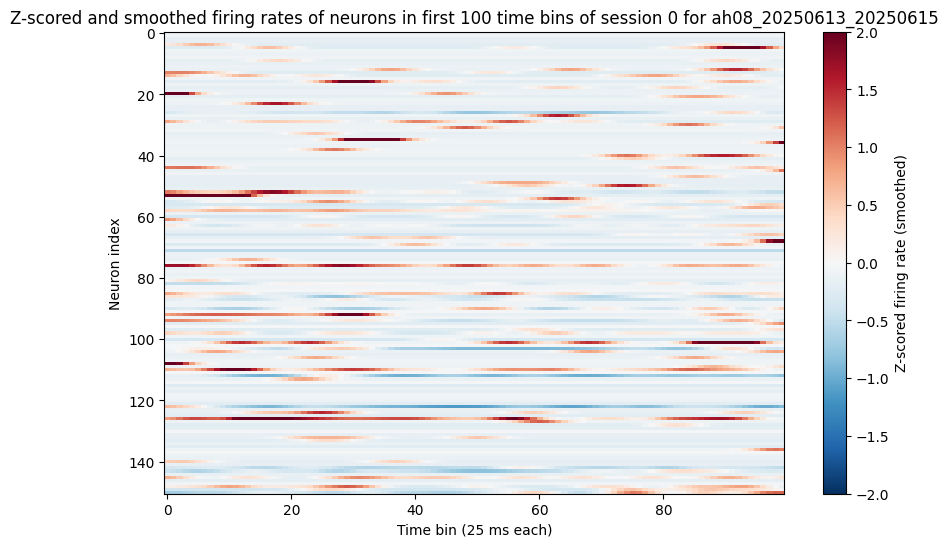

In [31]:

first_session_neurons = data_dic[mouse_recday][0]['Neuron_raw']*40 #get the Neuron_raw for the first sessionand convert to firing rates (since Neuron_raw is in units of spikes per sample, and there are 40 samples per second)
# Z-score each neuron's firing rate across the entire session
first_session_neurons_z = zscore(first_session_neurons, axis=1)
# Smooth the z-scored firing rates with a Gaussian filter (sigma=1 time bin)
first_session_neurons_z_smooth = gaussian_filter1d(first_session_neurons_z, sigma=3, axis=1)

plt.figure(figsize=(10, 6))
plt.imshow(first_session_neurons_z_smooth[:, :100], aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
plt.ylabel('Neuron index')
plt.xlabel('Time bin (25 ms each)')
plt.title(f'Z-scored and smoothed firing rates of neurons in first 100 time bins of session 0 for {mouse_recday}')
plt.colorbar(label='Z-scored firing rate (smoothed)')

In [ ]:
"""
A lot of analysis involves aligning neural data to specific events, like the start of state A, B, C, or D. 
We can use the 'Trial_times' array to do this alignment. 
For example, we can align the neural data to the start of state A for each trial, 
and then average across trials to get a trial-averaged response for each neuron aligned to state A.

Have a go at this in the cell below. You can choose a time window around the state A start (e.g. -1 second to +2 seconds), 
and then extract the neural data for that time window around each state A start, and average across trials.
"""

"\nA lot of analysis involves aligning neural data to specific events, like the start of state A, B, C, or D. \nWe can use the 'Trial_times' array to do this alignment. \nFor example, we can align the neural data to the start of state A for each trial, \nand then average across trials to get a trial-averaged response for each neuron aligned to state A.\n"